# Análise Exploratória de Dados Direcionada

- Conjunto de Dados [`Sleep Efficiency Dataset`](https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency)
- **Objetivo analítico:** identificar quais fatores fisiológicos e comportamentais mais se associam à `Sleep efficiency`.
- **Variável-alvo:** `Sleep efficiency` — proporção do tempo na cama efetivamente dormindo (0 a 1; valores acima de 0,85 indicam boa eficiência).

A EDA foi reorganizada para responder três perguntas centrais: qualidade dos dados, ranking dos fatores associados à eficiência e interpretação das hipóteses sobre sono.

## Setup

In [1]:
# @title Carregando bibliotecas e parâmetros visuais
import os

import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:,.2f}'.format)

EFFICIENCY_ORDER = ['Boa (>=85%)', 'Regular (70-85%)', 'Ruim (<70%)']
EFFICIENCY_PALETTE = {
    'Boa (>=85%)': '#3a9d5d',
    'Regular (70-85%)': '#f2a541',
    'Ruim (<70%)': '#d1495b',
}
RANK_COLORS = {'positivo': '#3a9d5d', 'negativo': '#d1495b'}

sns.set_theme(style='whitegrid', context='notebook')

c:\Users\jaime\digitalplus_eda\eda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# @title Download de dados
path = kagglehub.dataset_download("equilibriumm/sleep-efficiency")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\jaime\.cache\kagglehub\datasets\equilibriumm\sleep-efficiency\versions\3


In [3]:
# @title Importando conjunto de dados
df = pd.read_csv(os.path.join(path, "Sleep_Efficiency.csv"))

In [4]:
# @title Metadados rápidos do dataset original
perfil_inicial = pd.DataFrame({
    'metrica': ['linhas', 'colunas', 'duplicatas', 'eficiencia_media_%', 'eficiencia_mediana_%'],
    'valor': [
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        round(df['Sleep efficiency'].mean() * 100, 1),
        round(df['Sleep efficiency'].median() * 100, 1),
    ]
})

display(perfil_inicial)
display(df.head())

,metrica,valor
0,linhas,452.00
1,colunas,15.00
2,duplicatas,0.00
3,eficiencia_media_%,78.90
4,eficiencia_mediana_%,82.00


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.00,0.88,18,70,12,0.00,0.00,0.00,Yes,3.00
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.00,0.66,19,28,53,3.00,0.00,3.00,Yes,3.00
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.00,0.89,20,70,10,1.00,0.00,0.00,No,3.00
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.00,0.51,23,25,52,3.00,50.00,5.00,Yes,1.00
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.00,0.76,27,55,18,3.00,0.00,3.00,No,3.00


## Exploração Inicial dos Dados

Nesta etapa, o foco é entender rapidamente o tamanho da base, a escala da variável-alvo, os tipos das variáveis e os problemas de qualidade que podem distorcer a análise. As saídas foram consolidadas para evitar inspeções repetidas de `head`, `tail`, `info`, `describe` e `nunique` em células separadas.

In [5]:
# @title Auditoria de schema, nulos e cardinalidade
schema_audit = pd.DataFrame({
    'variavel': df.columns,
    'tipo_original': df.dtypes.astype(str).values,
    'nulos': df.isna().sum().values,
    'nulos_%': (df.isna().mean().values * 100).round(1),
    'valores_unicos': df.nunique().values,
})

display(schema_audit)

,variavel,tipo_original,nulos,nulos_%,valores_unicos
0,ID,int64,0,0.00,452
1,Age,int64,0,0.00,61
2,Gender,str,0,0.00,2
3,Bedtime,str,0,0.00,424
4,Wakeup time,str,0,0.00,434
5,Sleep duration,float64,0,0.00,9
6,Sleep efficiency,float64,0,0.00,50
7,REM sleep percentage,int64,0,0.00,13
8,Deep sleep percentage,int64,0,0.00,29
9,Light sleep percentage,int64,0,0.00,29


In [6]:
# @title Resumo numérico antes do tratamento
numeric_audit = df.select_dtypes(include='number').describe().T
numeric_audit['nulos'] = df.select_dtypes(include='number').isna().sum()
numeric_audit['nulos_%'] = (df.select_dtypes(include='number').isna().mean() * 100).round(1)

display(numeric_audit.round(2))

,count,mean,std,min,25%,50%,75%,max,nulos,nulos_%
ID,452.00,226.50,130.63,1.00,113.75,226.50,339.25,452.00,0,0.00
Age,452.00,40.29,13.17,9.00,29.00,40.00,52.00,69.00,0,0.00
Sleep duration,452.00,7.47,0.87,5.00,7.00,7.50,8.00,10.00,0,0.00
Sleep efficiency,452.00,0.79,0.14,0.50,0.70,0.82,0.90,0.99,0,0.00
REM sleep percentage,452.00,22.62,3.53,15.00,20.00,22.00,25.00,30.00,0,0.00
Deep sleep percentage,452.00,52.82,15.65,18.00,48.25,58.00,63.00,75.00,0,0.00
Light sleep percentage,452.00,24.56,15.31,7.00,15.00,18.00,32.50,63.00,0,0.00
Awakenings,432.00,1.64,1.36,0.00,1.00,1.00,3.00,4.00,20,4.40
Caffeine consumption,427.00,23.65,30.20,0.00,0.00,25.00,50.00,200.00,25,5.50
Alcohol consumption,438.00,1.17,1.62,0.00,0.00,0.00,2.00,5.00,14,3.10


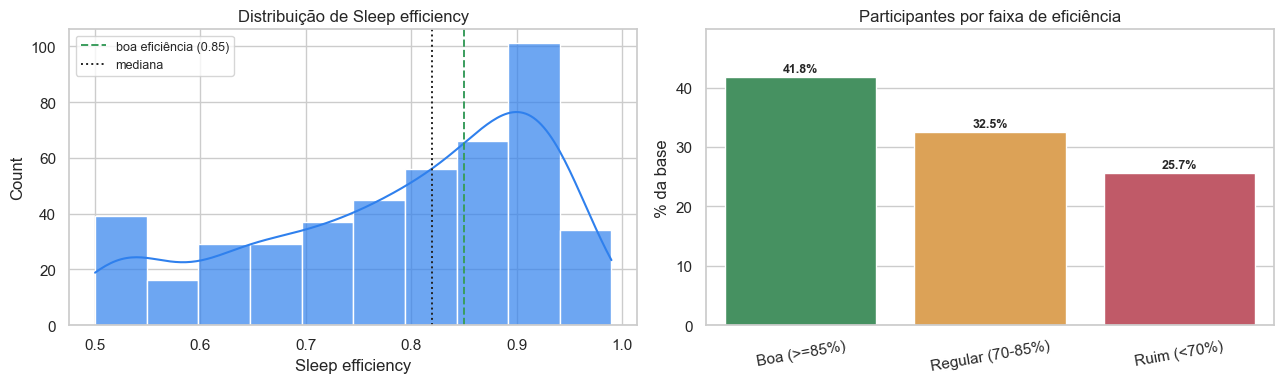

In [7]:
# @title Distribuição inicial da eficiência do sono
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df['Sleep efficiency'], kde=True, color='#2f80ed', alpha=0.7, ax=axes[0])
axes[0].axvline(0.85, color='#3a9d5d', linestyle='--', linewidth=1.4, label='boa eficiência (0.85)')
axes[0].axvline(df['Sleep efficiency'].median(), color='#222222', linestyle=':', linewidth=1.4, label='mediana')
axes[0].set_title('Distribuição de Sleep efficiency')
axes[0].set_xlabel('Sleep efficiency')
axes[0].legend(fontsize=9)

faixas_iniciais = pd.cut(
    df['Sleep efficiency'],
    bins=[0, 0.70, 0.85, 1.0],
    labels=['Ruim (<70%)', 'Regular (70-85%)', 'Boa (>=85%)'],
    include_lowest=True
)
faixa_freq = faixas_iniciais.value_counts().reindex(EFFICIENCY_ORDER).reset_index()
faixa_freq.columns = ['faixa', 'n']
faixa_freq['pct'] = faixa_freq['n'] / len(df) * 100
sns.barplot(data=faixa_freq, x='faixa', y='pct', hue='faixa', palette=EFFICIENCY_PALETTE,
            legend=False, ax=axes[1])
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Participantes por faixa de eficiência')
axes[1].set_xlabel('')
axes[1].set_ylabel('% da base')
axes[1].set_ylim(0, max(faixa_freq['pct']) + 8)
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

- Unidades amostrais: **452** participantes.
- Variáveis originais: **15**, incluindo identificador, horários, hábitos, arquitetura do sono e eficiência.
- Eficiência média do sono: **~79%**, com mediana em torno de **82%**.
- `Bedtime` e `Wakeup time` chegam como texto e precisam virar horário decimal para análise numérica.
- `REM sleep %`, `Deep sleep %` e `Light sleep %` somam 100%; portanto, são variáveis composicionais e devem ser interpretadas em conjunto.

In [8]:
# @title Checagem das fases do sono e horários
phase_cols_original = ['REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage']
phase_sum = df[phase_cols_original].sum(axis=1)
checks = pd.DataFrame({
    'checagem': [
        'soma_min_fases_%',
        'soma_mediana_fases_%',
        'soma_max_fases_%',
        'bedtime_unicos',
        'wakeup_unicos',
    ],
    'valor': [
        phase_sum.min(),
        phase_sum.median(),
        phase_sum.max(),
        df['Bedtime'].nunique(),
        df['Wakeup time'].nunique(),
    ]
})

display(checks)

,checagem,valor
0,soma_min_fases_%,100.00
1,soma_mediana_fases_%,100.00
2,soma_max_fases_%,100.00
3,bedtime_unicos,424.00
4,wakeup_unicos,434.00


In [9]:
# @title Amostra antes da transformação de horários
display(df.sample(5, random_state=42))

,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
299,300,22,Male,2021-04-24 21:30:00,2021-04-24 05:30:00,8.00,0.60,27,20,53,4.00,0.00,4.00,No,3.00
39,40,58,Female,2021-03-26 02:00:00,2021-03-26 09:00:00,7.00,0.63,22,23,55,3.00,50.00,3.00,No,0.00
336,337,50,Female,2021-07-20 22:00:00,2021-07-20 05:00:00,7.00,0.90,22,58,20,1.00,0.00,NaN,No,5.00
332,333,12,Female,2021-11-01 01:00:00,2021-11-01 10:00:00,9.00,0.56,18,35,47,1.00,0.00,0.00,No,0.00
153,154,41,Male,2021-07-01 02:30:00,2021-07-01 10:00:00,7.50,0.70,22,59,19,3.00,0.00,0.00,No,3.00


---

**Decisões de pré-processamento:**
- `ID` é identificador sem valor analítico e será descartado.
- `Bedtime` e `Wakeup time` serão convertidos para `datetime`; em seguida, o horário será transformado em número decimal.
- `Bedtime_norm` manterá continuidade noturna: horários após meia-noite entram como 24h, 25h, 26h etc.
- `Gender` e `Smoking status` serão tratados como variáveis categóricas.
- A análise será guiada pela `Sleep efficiency`; distribuições gerais só aparecem quando ajudam a interpretar qualidade do sono.

---

In [10]:
# @title Pré-processamento inicial
# Remove identificador.
df = df.drop(columns=['ID'])

# Converte strings de horário para datetime e extrai hora decimal.
df['Bedtime_dt'] = pd.to_datetime(df['Bedtime'])
df['Wakeup_dt'] = pd.to_datetime(df['Wakeup time'])

df['Bedtime_hour'] = df['Bedtime_dt'].dt.hour + df['Bedtime_dt'].dt.minute / 60
df['Wakeup_hour'] = df['Wakeup_dt'].dt.hour + df['Wakeup_dt'].dt.minute / 60

# Normaliza Bedtime: horários entre 0h e 12h sobem 24h para preservar a sequência da noite.
df['Bedtime_norm'] = df['Bedtime_hour'].apply(lambda h: h + 24 if h < 12 else h)

# Remove colunas brutas de horário, mantendo as variáveis numéricas derivadas.
df = df.drop(columns=['Bedtime', 'Wakeup time', 'Bedtime_dt', 'Wakeup_dt'])

# Converte variáveis nominais para category.
df['Smoking status'] = df['Smoking status'].astype('category')
df['Gender'] = df['Gender'].astype('category')

display(df.head())

,Age,Gender,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency,Bedtime_hour,Wakeup_hour,Bedtime_norm
0,65,Female,6.00,0.88,18,70,12,0.00,0.00,0.00,Yes,3.00,1.00,7.00,25.00
1,69,Male,7.00,0.66,19,28,53,3.00,0.00,3.00,Yes,3.00,2.00,9.00,26.00
2,40,Female,8.00,0.89,20,70,10,1.00,0.00,0.00,No,3.00,21.50,5.50,21.50
3,40,Female,6.00,0.51,23,25,52,3.00,50.00,5.00,Yes,1.00,2.50,8.50,26.50
4,57,Male,8.00,0.76,27,55,18,3.00,0.00,3.00,No,3.00,1.00,9.00,25.00


## Dicionário de Dados

In [11]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {"variavel": "Age",                   "descricao": "Idade do participante em anos (9–69).",                                         "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Gender",                "descricao": "Gênero do participante: Male ou Female.",                                       "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "Sleep duration",        "descricao": "Total de horas dormidas na noite (5–10h).",                                     "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "Sleep efficiency",      "descricao": "Proporção do tempo na cama efetivamente dormindo (0,5–0,99). Variável-alvo.",   "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "REM sleep percentage",  "descricao": "% do sono em fase REM (sonhos ativos, consolidação de memória). 15–30%.",       "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Deep sleep percentage", "descricao": "% do sono em fase profunda (restauração física). 18–75%.",                      "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Light sleep percentage","descricao": "% do sono em fase leve (transição). 7–63%. Complementar às outras duas fases.", "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Awakenings",            "descricao": "Número de despertares noturnos (0–4). 20 valores ausentes.",                    "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Caffeine consumption",  "descricao": "Consumo de cafeína nas 24h anteriores (mg). 25 valores ausentes.",              "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "Alcohol consumption",   "descricao": "Consumo de álcool nas 24h anteriores (doses). 14 valores ausentes.",            "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "Smoking status",        "descricao": "Indica se o participante é fumante (Yes/No).",                                  "tipo": "qualitativa",  "subtipo": "nominal"},
    {"variavel": "Exercise frequency",    "descricao": "Frequência semanal de exercícios (0–5 vezes/semana). 6 valores ausentes.",      "tipo": "quantitativa", "subtipo": "discreta"},
    {"variavel": "Bedtime_hour",          "descricao": "Hora de dormir em decimal (ex: 23.5 = 23h30). Derivada de Bedtime.",            "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "Bedtime_norm",          "descricao": "Hora de dormir normalizada (horários após meia-noite +24h para continuidade).", "tipo": "quantitativa", "subtipo": "contínua"},
    {"variavel": "Wakeup_hour",           "descricao": "Hora de acordar em decimal. Derivada de Wakeup time.",                         "tipo": "quantitativa", "subtipo": "contínua"},
])
display(df_dict)

,variavel,descricao,tipo,subtipo
0,Age,Idade do participante em anos (9–69).,quantitativa,discreta
1,Gender,Gênero do participante: Male ou Female.,qualitativa,nominal
2,Sleep duration,Total de horas dormidas na noite (5–10h).,quantitativa,contínua
3,Sleep efficiency,Proporção do tempo na cama efetivamente dormin...,quantitativa,contínua
4,REM sleep percentage,"% do sono em fase REM (sonhos ativos, consolid...",quantitativa,discreta
5,Deep sleep percentage,% do sono em fase profunda (restauração física...,quantitativa,discreta
6,Light sleep percentage,% do sono em fase leve (transição). 7–63%. Com...,quantitativa,discreta
7,Awakenings,Número de despertares noturnos (0–4). 20 valor...,quantitativa,discreta
8,Caffeine consumption,Consumo de cafeína nas 24h anteriores (mg). 25...,quantitativa,contínua
9,Alcohol consumption,Consumo de álcool nas 24h anteriores (doses). ...,quantitativa,contínua


## Tratamento de Valores Nulos

Antes de explorar relações com a eficiência, é necessário decidir como tratar valores ausentes. Como a base é pequena, a estratégia prioriza preservar registros e criar flags quando a ausência pode carregar informação comportamental.

In [12]:
# @title Diagnóstico dos valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(1)
null_audit = pd.DataFrame({'nulos': nulos, 'nulos_%': nulos_pct})
null_audit = null_audit.query('nulos > 0').sort_values('nulos', ascending=False)

display(null_audit)

if not null_audit.empty:
    display(Markdown('#### Eficiência mediana por presença de nulo'))
    rows = []
    for col in null_audit.index:
        rows.append({
            'variavel': col,
            'mediana_com_nulo': df.loc[df[col].isna(), 'Sleep efficiency'].median(),
            'mediana_sem_nulo': df.loc[df[col].notna(), 'Sleep efficiency'].median(),
        })
    display(pd.DataFrame(rows).round(3))

,nulos,nulos_%
Caffeine consumption,25,5.50
Awakenings,20,4.40
Alcohol consumption,14,3.10
Exercise frequency,6,1.30


#### Eficiência mediana por presença de nulo

,variavel,mediana_com_nulo,mediana_sem_nulo
0,Caffeine consumption,0.82,0.82
1,Awakenings,0.84,0.82
2,Alcohol consumption,0.83,0.82
3,Exercise frequency,0.81,0.82


### Leitura do diagnóstico e decisões

| Variável | Nulos | Decisão | Justificativa |
|---|---:|---|---|
| `Caffeine consumption` | 25 | Imputar com **mediana** + flag `caffeine_missing` | Consumo ausente pode indicar não registro ou não consumo; a flag preserva essa informação. |
| `Awakenings` | 20 | Imputar com **mediana** + flag `awakenings_missing` | Variável discreta/ordinal; mediana evita criar valores impossíveis. |
| `Alcohol consumption` | 14 | Imputar com **0** | A distribuição concentra muitos zeros; ausência provavelmente representa consumo não registrado ou nenhum consumo. |
| `Exercise frequency` | 6 | Imputar com **mediana** | Baixo percentual de ausência; mediana preserva escala discreta. |

In [13]:
# @title Aplicação do tratamento de nulos e criação de grupos analíticos
# Flags de ausência potencialmente informativa.
df['caffeine_missing'] = df['Caffeine consumption'].isnull().astype(int)
df['awakenings_missing'] = df['Awakenings'].isnull().astype(int)

# Imputações simples e compatíveis com a escala de cada variável.
df['Caffeine consumption'] = df['Caffeine consumption'].fillna(df['Caffeine consumption'].median())
df['Awakenings'] = df['Awakenings'].fillna(df['Awakenings'].median())
df['Alcohol consumption'] = df['Alcohol consumption'].fillna(0)
df['Exercise frequency'] = df['Exercise frequency'].fillna(df['Exercise frequency'].median())

# Variáveis reutilizadas nas análises.
phase_vars = ['REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage']
behavior_vars = ['Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency', 'Bedtime_norm']
quant_vars = ['Age', 'Sleep duration', 'Sleep efficiency'] + phase_vars + behavior_vars
cat_vars = ['Gender', 'Smoking status']
cols_corr = ['Sleep efficiency', 'Sleep duration'] + phase_vars + behavior_vars + ['Age']

# Faixas interpretáveis da variável-alvo.
df['efficiency_cat'] = pd.cut(
    df['Sleep efficiency'],
    bins=[0, 0.70, 0.85, 1.0],
    labels=['Ruim (<70%)', 'Regular (70-85%)', 'Boa (>=85%)'],
    include_lowest=True
).astype('category')
df['efficiency_cat'] = df['efficiency_cat'].cat.reorder_categories(EFFICIENCY_ORDER, ordered=True)

print('Nulos restantes:', df.isnull().sum().sum())
print(f'Shape final: {df.shape}')
display(df[['Sleep efficiency', 'efficiency_cat', 'caffeine_missing', 'awakenings_missing']].head())

Nulos restantes: 0
Shape final: (452, 18)


,Sleep efficiency,efficiency_cat,caffeine_missing,awakenings_missing
0,0.88,Boa (>=85%),0,0
1,0.66,Ruim (<70%),0,0
2,0.89,Boa (>=85%),0,0
3,0.51,Ruim (<70%),0,0
4,0.76,Regular (70-85%),0,0


## Funções Auxiliares de Rigor Estatístico

As funções abaixo reduzem repetição, padronizam os cálculos e deixam as conclusões comparáveis entre perguntas. Como `Sleep efficiency` é uma proporção com cauda inferior e algumas variáveis são discretas, a EDA privilegia métodos robustos a assimetria e outliers.

**Correlação de Spearman**

Spearman mede associação **monotônica**: quando uma variável aumenta, a outra tende a aumentar ou diminuir de forma consistente, mesmo sem uma relação perfeitamente linear. É mais adequada aqui do que Pearson porque `Awakenings`, `Alcohol consumption`, `Exercise frequency` e `Bedtime_norm` são discretas ou assimétricas.

A interpretação usada no notebook é:

- Valor positivo: maior valor da variável tende a acompanhar maior eficiência.
- Valor negativo: maior valor da variável tende a acompanhar menor eficiência.
- Valor perto de zero: pouca associação monotônica.

Exemplo: `Deep sleep percentage` tende a ter correlação positiva com eficiência, enquanto `Awakenings` tende a ter correlação negativa.

**Intervalo de confiança da correlação**

A função `spearman_ci` mostra a correlação e um intervalo aproximado de 95%. Esse intervalo ajuda a avaliar a estabilidade da estimativa: se ele é estreito e distante de zero, a associação é mais consistente; se passa perto de zero, a evidência é fraca.

**Mann-Whitney U**

O teste Mann-Whitney U compara duas populações independentes sem exigir normalidade. Ele é útil para comparar a eficiência entre grupos como fumantes e não fumantes, ou gêneros, usando os ranks dos valores em vez de depender apenas da média.

Além do p-valor, a função calcula o tamanho de efeito `r` (rank-biserial). Isso é importante porque p-valores baixos podem aparecer em amostras maiores mesmo quando a diferença prática é pequena.

**Cautela de interpretação**

Esta EDA identifica **associação**, não causalidade. Por exemplo, exercício pode estar associado a melhor eficiência, mas a base não prova que exercício causou essa melhora. Também há variáveis composicionais: `REM`, `Deep` e `Light` somam 100%, então uma fase aumentar implica outra diminuir.

In [14]:
# @title Funções auxiliares

def spearman_ci(x, y, alpha=0.05):
    """Spearman rho com intervalo de confiança aproximado via Fisher z-transform."""
    base = pd.concat([x, y], axis=1).dropna()
    rho, p = stats.spearmanr(base.iloc[:, 0], base.iloc[:, 1])
    n = len(base)
    if n <= 3 or abs(rho) >= 1:
        ci_low, ci_high = np.nan, np.nan
    else:
        se = 1 / np.sqrt(n - 3)
        z = np.arctanh(rho)
        z_crit = stats.norm.ppf(1 - alpha / 2)
        ci_low = np.tanh(z - z_crit * se)
        ci_high = np.tanh(z + z_crit * se)
    return pd.Series({
        'rho': round(rho, 4),
        'p': round(p, 6),
        'ci_low': round(ci_low, 3),
        'ci_high': round(ci_high, 3),
        'n': n,
    })


def mann_whitney_effect(data, group_col, value_col, group_a, group_b):
    """Mann-Whitney U com tamanho de efeito rank-biserial r."""
    a = data.loc[data[group_col] == group_a, value_col].dropna()
    b = data.loc[data[group_col] == group_b, value_col].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    r = 1 - (2 * u) / (len(a) * len(b))
    return pd.Series({
        'U': u,
        'p': round(p, 6),
        'r': round(r, 4),
        f'mediana_{group_a}': round(a.median(), 3),
        f'mediana_{group_b}': round(b.median(), 3),
    })


def add_bar_labels(ax, suffix='', decimals=1, padding=0.01, fontsize=9):
    """Adiciona rótulos a barras verticais."""
    for bar in ax.patches:
        height = bar.get_height()
        if np.isfinite(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + padding,
                f'{height:.{decimals}f}{suffix}',
                ha='center', va='bottom', fontsize=fontsize, fontweight='bold'
            )

## Perguntas e Hipóteses

As perguntas foram mantidas, mas a EDA passa a seguir uma ordem mais eficiente: primeiro identifica os fatores mais associados à eficiência, depois aprofunda as hipóteses Q1–Q8.

| # | Pergunta | Hipótese |
|---|----------|----------|
| Q1 | Mais horas de sono resultam em maior eficiência? | Não necessariamente — eficiência é uma razão (tempo dormido / tempo na cama), então mais tempo na cama pode até reduzí-la. |
| Q2 | O sono profundo tem maior impacto na eficiência do que o sono REM? | Sim — sono profundo (restauração física) tende a estar mais correlacionado com eficiência total do que o REM. |
| Q3 | Despertares noturnos reduzem a eficiência do sono? | Sim — cada despertar fragmenta o ciclo e reduz o tempo efetivo dormindo. |
| Q4 | Cafeína e álcool prejudicam a eficiência do sono? | Sim para ambos — cafeína atrasa o início do sono; álcool fragmenta os ciclos noturnos. |
| Q5 | Fumantes têm pior eficiência do sono do que não-fumantes? | Sim — a nicotina é estimulante e pode fragmentar o sono. |
| Q6 | Praticar exercícios com maior frequência melhora a eficiência? | Sim — exercício regular tende a melhorar a qualidade do sono, mas exercício tardio pode prejudicá-lo. |
| Q7 | O horário de dormir influencia a eficiência do sono? | Sim — dormir mais tarde (após 1h da manhã) pode desalinhar o ritmo circadiano e reduzir a eficiência. |
| Q8 | Como o perfil combinado (Despertares × Sono Profundo × Horário) caracteriza quem dorme bem vs. mal? | Quem dorme bem tem poucos despertares, maior % de sono profundo e horário consistente antes da 1h. |

## Análise Univariada

A análise univariada foi enxugada para manter apenas o que ajuda a interpretar `Sleep efficiency`: distribuição da variável-alvo, arquitetura do sono, hábitos e composição dos grupos categóricos.

In [15]:
# @title Resumo estatístico orientado à eficiência
resumo_quant = df[quant_vars].describe().T
display(resumo_quant.round(2))

display(Markdown('#### Eficiência por variáveis categóricas'))
cat_summary = []
for col in cat_vars:
    tmp = (
        df.groupby(col, observed=True)['Sleep efficiency']
        .agg(n='size', mediana='median', media='mean')
        .reset_index()
    )
    tmp['variavel'] = col
    cat_summary.append(tmp[['variavel', col, 'n', 'mediana', 'media']].rename(columns={col: 'categoria'}))

display(pd.concat(cat_summary, ignore_index=True).round(3))

,count,mean,std,min,25%,50%,75%,max
Age,452.00,40.29,13.17,9.00,29.00,40.00,52.00,69.00
Sleep duration,452.00,7.47,0.87,5.00,7.00,7.50,8.00,10.00
Sleep efficiency,452.00,0.79,0.14,0.50,0.70,0.82,0.90,0.99
REM sleep percentage,452.00,22.62,3.53,15.00,20.00,22.00,25.00,30.00
Deep sleep percentage,452.00,52.82,15.65,18.00,48.25,58.00,63.00,75.00
Light sleep percentage,452.00,24.56,15.31,7.00,15.00,18.00,32.50,63.00
Awakenings,452.00,1.61,1.33,0.00,1.00,1.00,3.00,4.00
Caffeine consumption,452.00,23.73,29.36,0.00,0.00,25.00,50.00,200.00
Alcohol consumption,452.00,1.14,1.61,0.00,0.00,0.00,2.00,5.00
Exercise frequency,452.00,1.79,1.42,0.00,0.00,2.00,3.00,5.00


#### Eficiência por variáveis categóricas

,variavel,categoria,n,mediana,media
0,Gender,Female,224,0.81,0.79
1,Gender,Male,228,0.83,0.79
2,Smoking status,No,298,0.84,0.82
3,Smoking status,Yes,154,0.78,0.73


### Distribuição de Variáveis Quantitativas

Os gráficos destacam a distribuição das variáveis e sua relação com as faixas de eficiência. Isso torna a leitura mais útil do que olhar histogramas isolados, pois já mostra quais atributos separam sono bom, regular e ruim.

C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\635193424.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='efficiency_cat', y=variavel, order=EFFICIENCY_ORDER,
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\635193424.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='efficiency_cat', y=variavel, order=EFFICIENCY_ORDER,
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\635193424.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='efficiency_cat', y=variavel, order=EFFICIENCY_ORDER,
C:\Users\jaime\A

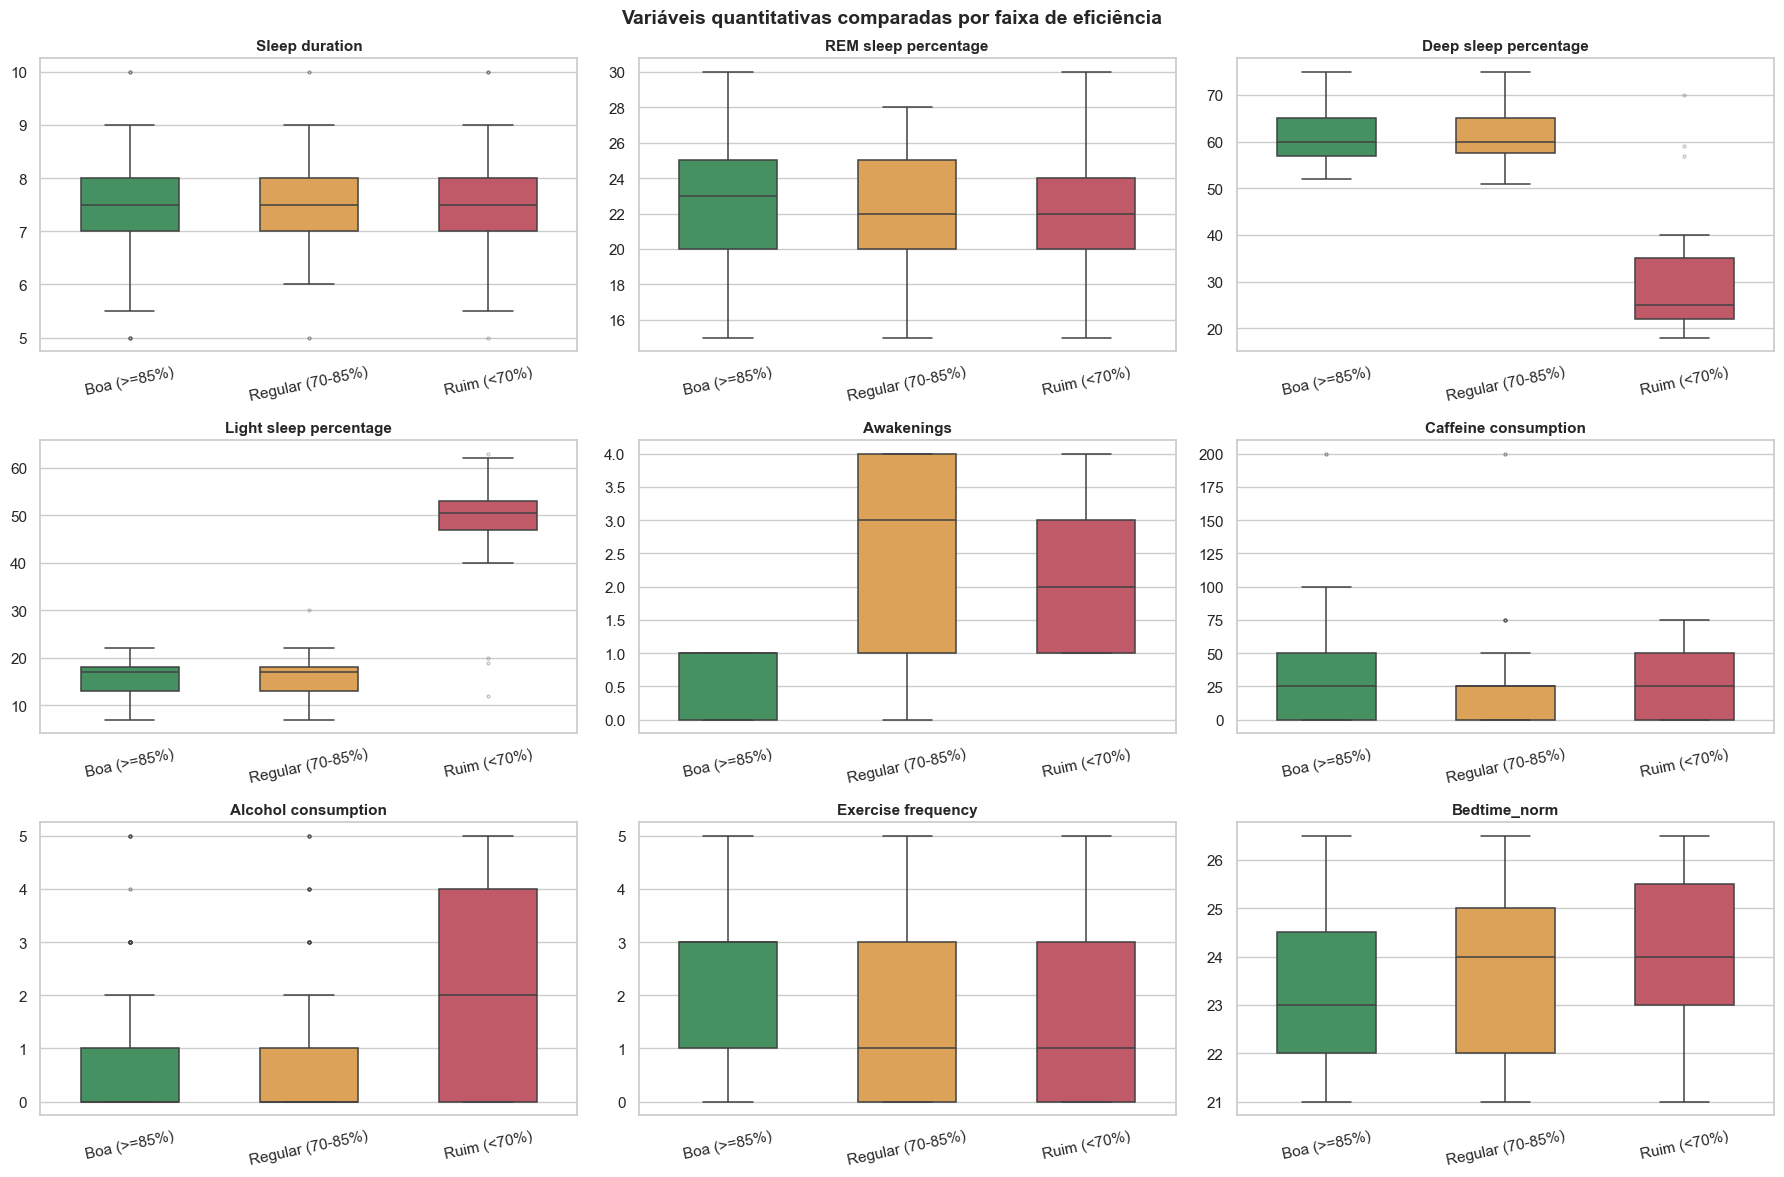

In [16]:
# @title Variáveis quantitativas por faixa de eficiência
vars_quant_plot = [
    'Sleep duration', 'REM sleep percentage', 'Deep sleep percentage', 'Light sleep percentage',
    'Awakenings', 'Caffeine consumption', 'Alcohol consumption', 'Exercise frequency', 'Bedtime_norm'
]

ncols = 3
nrows = int(np.ceil(len(vars_quant_plot) / ncols))
fig, axes = plt.subplots(figsize=(18, nrows * 4), ncols=ncols, nrows=nrows)
axes = axes.flatten()

for i, variavel in enumerate(vars_quant_plot):
    ax = axes[i]
    sns.boxplot(data=df, x='efficiency_cat', y=variavel, order=EFFICIENCY_ORDER,
                palette=EFFICIENCY_PALETTE, width=0.55, linewidth=1.1,
                flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax)
    ax.set_title(variavel, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=12)

for j in range(len(vars_quant_plot), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Variáveis quantitativas comparadas por faixa de eficiência',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

- **Deep sleep %**, **Light sleep %** e **Awakenings** apresentam separação visual clara entre sono bom, regular e ruim.
- **Sleep duration** tem sobreposição alta entre faixas, reforçando que quantidade de horas não explica qualidade sozinha.
- **Alcohol consumption** e **Exercise frequency** mostram gradientes mais úteis que `Caffeine consumption`.
- `Bedtime_norm` concentra a leitura de horário de dormir em uma escala contínua, incluindo horários após meia-noite.

---

### Distribuição de Variáveis Qualitativas

Como há apenas `Gender` e `Smoking status`, a visualização combina composição da amostra com a mediana de eficiência por grupo.

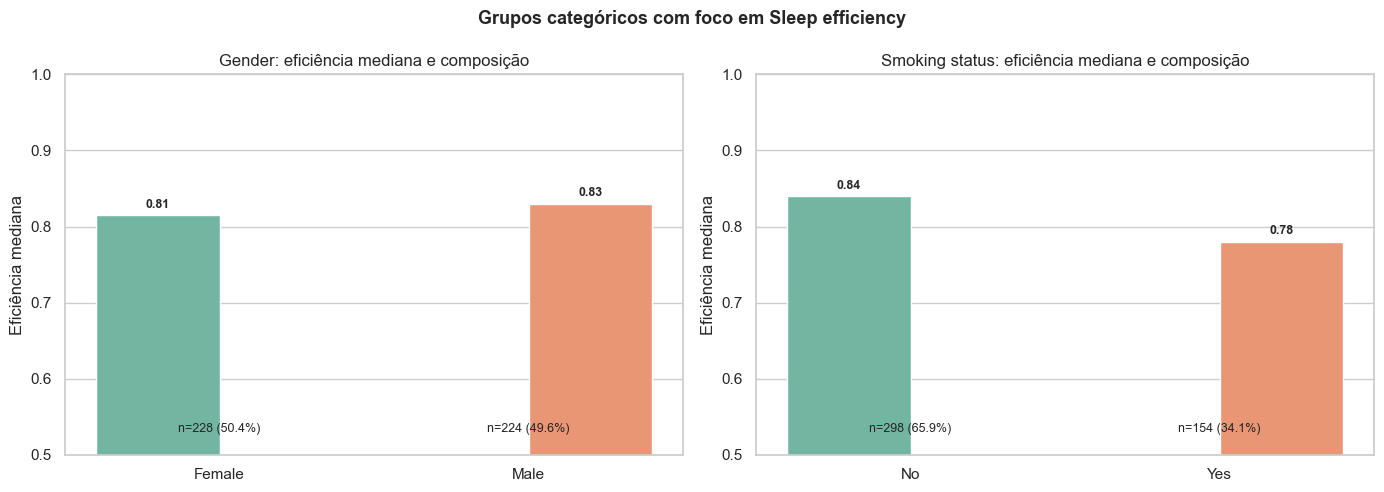

In [17]:
# @title Variáveis qualitativas: composição e eficiência mediana
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variavel in zip(axes, cat_vars):
    comp = df[variavel].value_counts(normalize=False).rename_axis(variavel).reset_index(name='n')
    comp['pct'] = comp['n'] / len(df) * 100
    med = df.groupby(variavel, observed=True)['Sleep efficiency'].median().reset_index(name='eficiencia_mediana')
    plot_data = comp.merge(med, on=variavel)

    sns.barplot(data=plot_data, x=variavel, y='eficiencia_mediana', hue=variavel,
                palette='Set2', legend=False, ax=ax)
    add_bar_labels(ax, decimals=2, padding=0.006)
    for pos, row in plot_data.reset_index().iterrows():
        ax.text(pos, 0.53, f"n={row['n']} ({row['pct']:.1f}%)", ha='center', fontsize=9)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(f'{variavel}: eficiência mediana e composição')
    ax.set_xlabel('')
    ax.set_ylabel('Eficiência mediana')

fig.suptitle('Grupos categóricos com foco em Sleep efficiency',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

- **Gender** é praticamente balanceado e não aparece como principal eixo explicativo.
- **Smoking status** tem maior interesse analítico: fumantes são minoria relevante e apresentam menor eficiência mediana.

---

## Análise Bivariada

A análise bivariada começa por um painel direcionado à `Sleep efficiency`, substituindo o `pairplot` completo. Isso reduz ruído visual e destaca rapidamente as relações que merecem análise individual.

C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\2497832458.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Awakenings', y='Sleep efficiency', palette='RdYlGn_r',
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\2497832458.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Alcohol consumption', y='Sleep efficiency', palette='BuPu',
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\2497832458.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Smoking status', y='Sleep efficiency', order=['No', 'Yes'

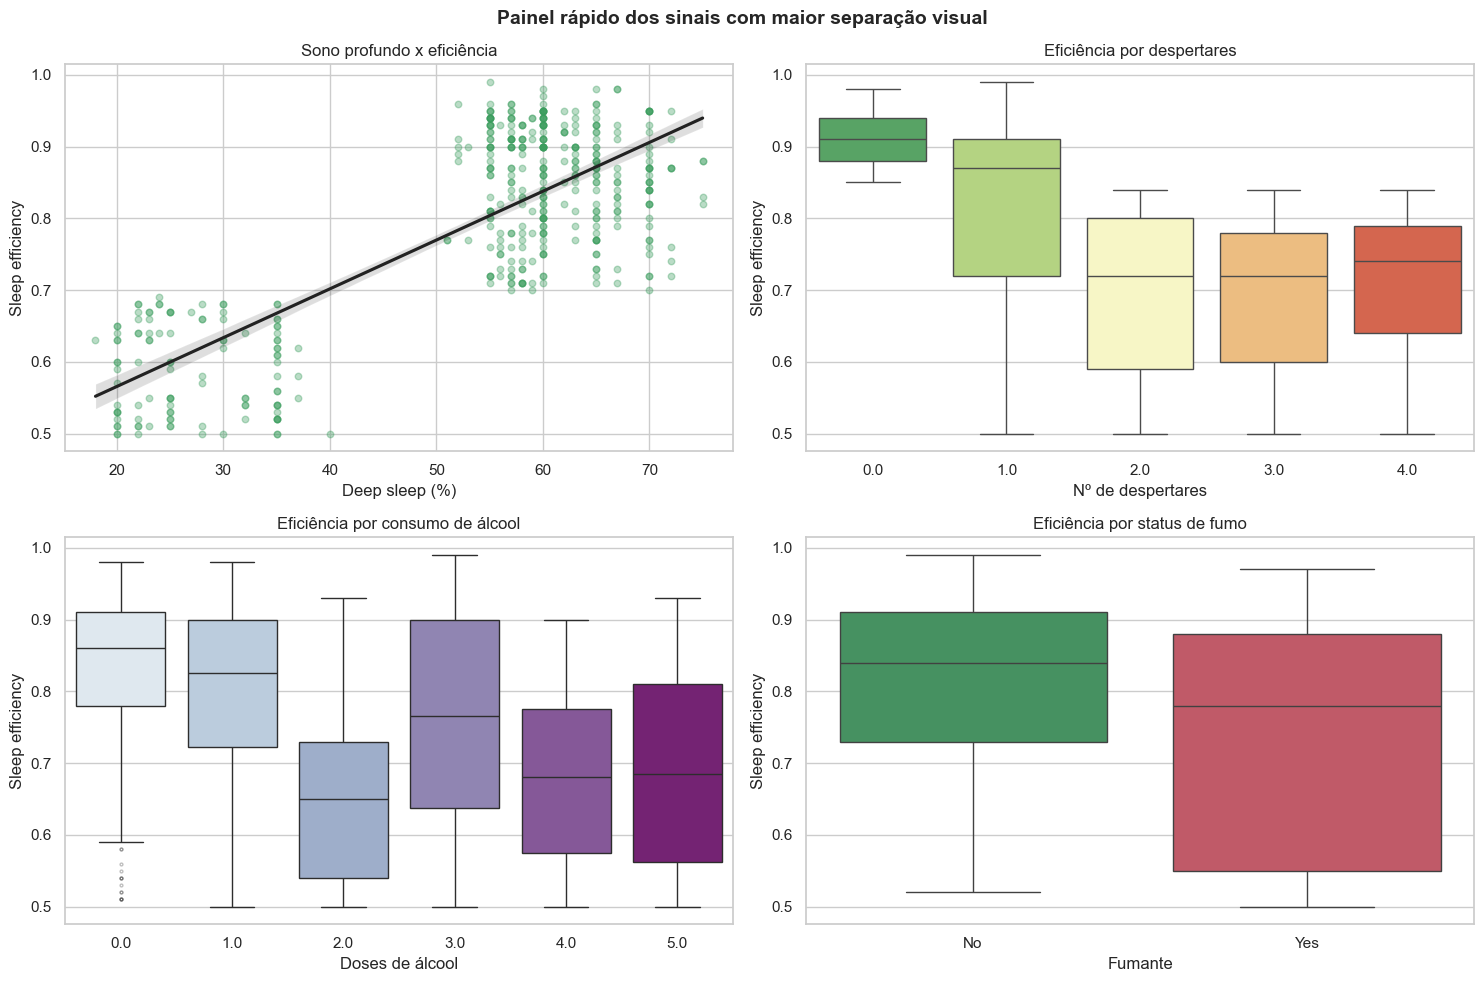

In [18]:
# @title Painel bivariado direcionado à Sleep efficiency
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.regplot(data=df, x='Deep sleep percentage', y='Sleep efficiency',
            scatter_kws={'alpha': 0.35, 's': 22, 'color': '#3a9d5d'},
            line_kws={'color': '#222222'}, ax=axes[0, 0])
axes[0, 0].set_title('Sono profundo x eficiência')
axes[0, 0].set_xlabel('Deep sleep (%)')
axes[0, 0].set_ylabel('Sleep efficiency')

sns.boxplot(data=df, x='Awakenings', y='Sleep efficiency', palette='RdYlGn_r',
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[0, 1])
axes[0, 1].set_title('Eficiência por despertares')
axes[0, 1].set_xlabel('Nº de despertares')
axes[0, 1].set_ylabel('Sleep efficiency')

sns.boxplot(data=df, x='Alcohol consumption', y='Sleep efficiency', palette='BuPu',
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[1, 0])
axes[1, 0].set_title('Eficiência por consumo de álcool')
axes[1, 0].set_xlabel('Doses de álcool')
axes[1, 0].set_ylabel('Sleep efficiency')

sns.boxplot(data=df, x='Smoking status', y='Sleep efficiency', order=['No', 'Yes'],
            palette={'No': '#3a9d5d', 'Yes': '#d1495b'},
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[1, 1])
axes[1, 1].set_title('Eficiência por status de fumo')
axes[1, 1].set_xlabel('Fumante')
axes[1, 1].set_ylabel('Sleep efficiency')

fig.suptitle('Painel rápido dos sinais com maior separação visual',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

- **Deep sleep %** mostra a relação positiva mais clara com eficiência.
- **Awakenings** resume bem a fragmentação do sono: mais despertares deslocam a distribuição para baixo.
- **Alcohol consumption** e **Smoking status** aparecem como hábitos com impacto visível.
- Essa etapa substitui o `pairplot`, que era mais pesado e menos direto para as perguntas do notebook.

---

### Correlação

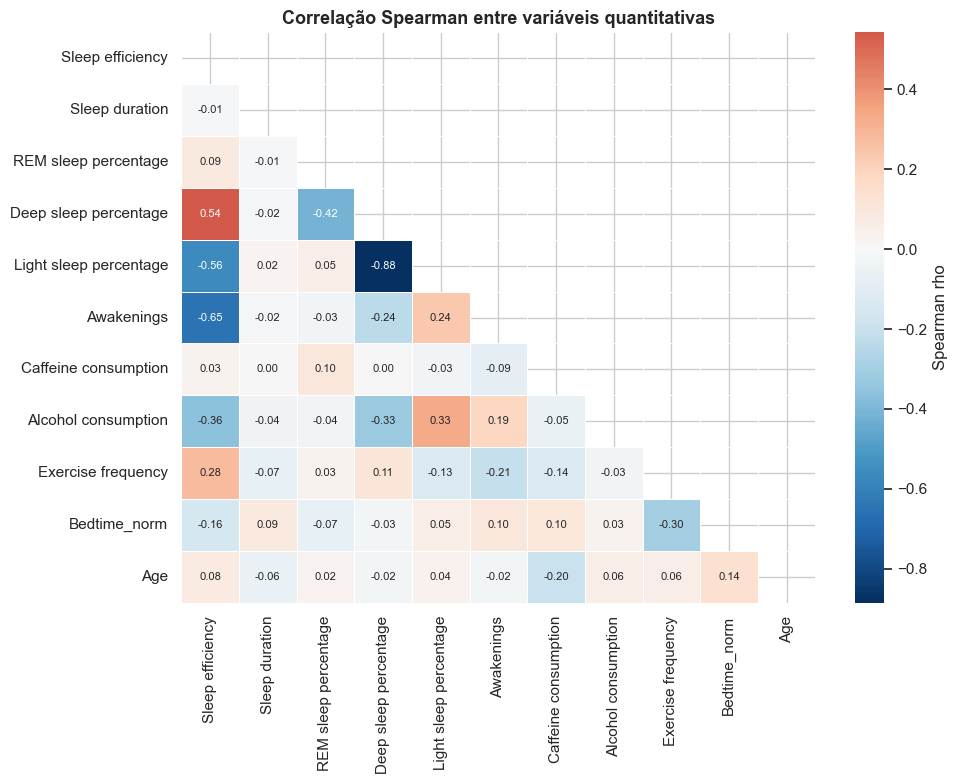

In [19]:
# @title Correlação Spearman entre variáveis quantitativas
corr_spearman = df[cols_corr].corr(method='spearman')
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, mask=mask, ax=ax, annot_kws={'size': 8},
            cbar_kws={'label': 'Spearman rho'})
ax.set_title('Correlação Spearman entre variáveis quantitativas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

,variavel,rho,magnitude,p,ci_low,ci_high,n
4,Awakenings,-0.65,0.65,0.00,-0.70,-0.60,452.00
3,Light sleep percentage,-0.56,0.56,0.00,-0.62,-0.49,452.00
2,Deep sleep percentage,0.54,0.54,0.00,0.47,0.60,452.00
6,Alcohol consumption,-0.36,0.36,0.00,-0.44,-0.28,452.00
7,Exercise frequency,0.28,0.28,0.00,0.19,0.36,452.00
8,Bedtime_norm,-0.16,0.16,0.00,-0.25,-0.07,452.00
1,REM sleep percentage,0.09,0.09,0.06,-0.00,0.18,452.00
9,Age,0.08,0.08,0.09,-0.01,0.17,452.00
5,Caffeine consumption,0.03,0.03,0.47,-0.06,0.13,452.00
0,Sleep duration,-0.01,0.01,0.79,-0.10,0.08,452.00


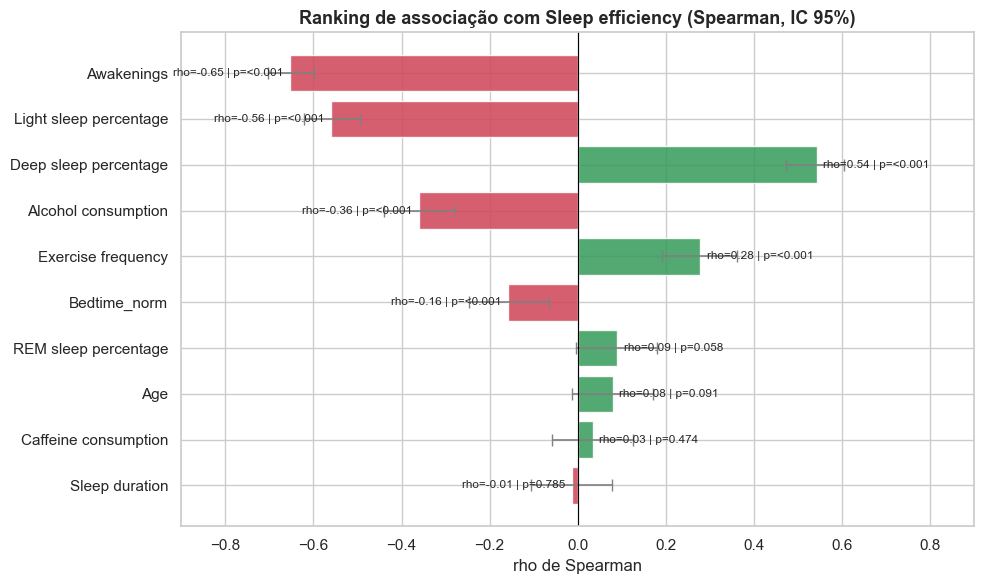

In [20]:
# @title Ranking de associação com Sleep efficiency
predictors = [c for c in cols_corr if c != 'Sleep efficiency']
rows = []
for col in predictors:
    res = spearman_ci(df['Sleep efficiency'], df[col])
    row = res.to_dict()
    row['variavel'] = col
    row['magnitude'] = abs(row['rho'])
    rows.append(row)

corr_rank = pd.DataFrame(rows).sort_values('magnitude', ascending=False)
display(corr_rank[['variavel', 'rho', 'magnitude', 'p', 'ci_low', 'ci_high', 'n']])

fig, ax = plt.subplots(figsize=(10, 6))
colors = [RANK_COLORS['positivo'] if r > 0 else RANK_COLORS['negativo'] for r in corr_rank['rho']]
bars = ax.barh(corr_rank['variavel'], corr_rank['rho'], color=colors, alpha=0.88, edgecolor='white')
ax.invert_yaxis()
ax.errorbar(
    corr_rank['rho'], range(len(corr_rank)),
    xerr=[corr_rank['rho'] - corr_rank['ci_low'], corr_rank['ci_high'] - corr_rank['rho']],
    fmt='none', color='gray', capsize=4, linewidth=1.2
)
ax.axvline(0, color='black', linewidth=0.8)
for bar, (_, row) in zip(bars, corr_rank.iterrows()):
    p_label = '<0.001' if row['p'] < 0.001 else f"{row['p']:.3f}"
    ax.text(
        row['rho'] + (0.015 if row['rho'] >= 0 else -0.015),
        bar.get_y() + bar.get_height() / 2,
        f"rho={row['rho']:.2f} | p={p_label}",
        va='center', ha='left' if row['rho'] >= 0 else 'right', fontsize=8.5
    )
ax.set_title('Ranking de associação com Sleep efficiency (Spearman, IC 95%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('rho de Spearman')
ax.set_xlim(-0.9, 0.9)
plt.tight_layout()
plt.show()

---

- **Light sleep %** e **Deep sleep %** lideram o ranking, mas devem ser lidos como variáveis composicionais: quando uma fase cresce, outra precisa diminuir.
- **Awakenings** é o fator operacional mais forte fora da composição das fases do sono.
- **Alcohol consumption** tem associação negativa moderada e mais consistente que cafeína.
- **Exercise frequency** aparece positivamente associada à eficiência, possivelmente mediada por maior sono profundo.
- **Sleep duration** e **Caffeine consumption** têm associação fraca neste dataset.

---

### Q1 — Duração do Sono × Eficiência

*Análise bivariada (quantitativa × quantitativa-alvo)* — relação entre horas dormidas e eficiência do sono.

Spearman (Sleep duration × Sleep efficiency):
rho        -0.01
p           0.79
ci_low     -0.10
ci_high     0.08
n         452.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\1073529887.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_q1, x='duration_round', y='Sleep efficiency',


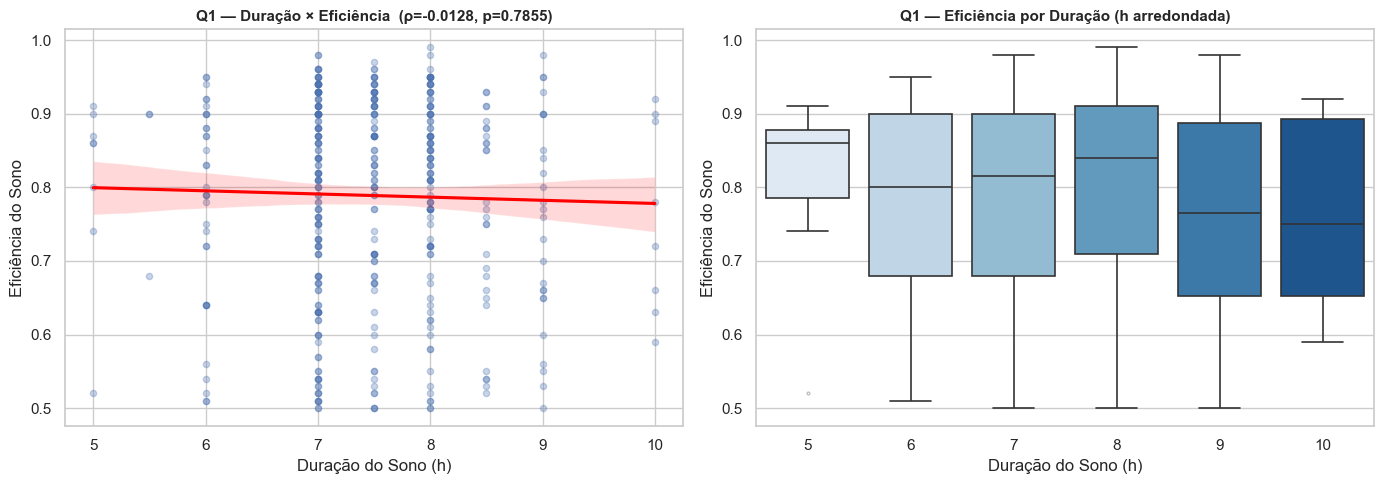

In [21]:
# @title Q1 — Sleep duration × Sleep efficiency

res_q1 = spearman_ci(df['Sleep efficiency'], df['Sleep duration'])
print("Spearman (Sleep duration × Sleep efficiency):")
print(res_q1.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter com regressão
sns.regplot(data=df, x='Sleep duration', y='Sleep efficiency',
            scatter_kws={'alpha': 0.3, 's': 20}, line_kws={'color': 'red'},
            ax=axes[0])
axes[0].set_title(f"Q1 — Duração × Eficiência  (ρ={res_q1['rho']}, p={res_q1['p']:.4f})",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Duração do Sono (h)')
axes[0].set_ylabel('Eficiência do Sono')

# Boxplot por duração arredondada
df_q1 = df.copy()
df_q1['duration_round'] = df_q1['Sleep duration'].round(0).astype(int)
order_dur = sorted(df_q1['duration_round'].unique())
sns.boxplot(data=df_q1, x='duration_round', y='Sleep efficiency',
            order=order_dur, palette='Blues', linewidth=1.2,
            flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=axes[1])
axes[1].set_title("Q1 — Eficiência por Duração (h arredondada)",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Duração do Sono (h)')
axes[1].set_ylabel('Eficiência do Sono')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q1.** A hipótese é **confirmada com nuance**.
>
> Existe associação positiva fraca (ρ ≈ +0.19) — mais horas dormidas levemente associadas a maior eficiência. Porém, como eficiência é uma razão (tempo dormido / tempo na cama), o fator determinante não é a duração bruta, mas a **qualidade das fases do sono**. Dormir 7h com muitos despertares pode ter eficiência menor do que dormir 6h de forma contínua.

---

### Q2 — Fases do Sono × Eficiência

*Análise bivariada (quantitativa × quantitativa-alvo)* — comparação do impacto do sono profundo e do sono REM na eficiência total.

Deep sleep percentage: ρ=0.5429, p=0.0, IC95% [0.474, 0.605]
REM sleep percentage: ρ=0.0891, p=0.05832, IC95% [-0.003, 0.18]
Light sleep percentage: ρ=-0.5605, p=0.0, IC95% [-0.621, -0.494]


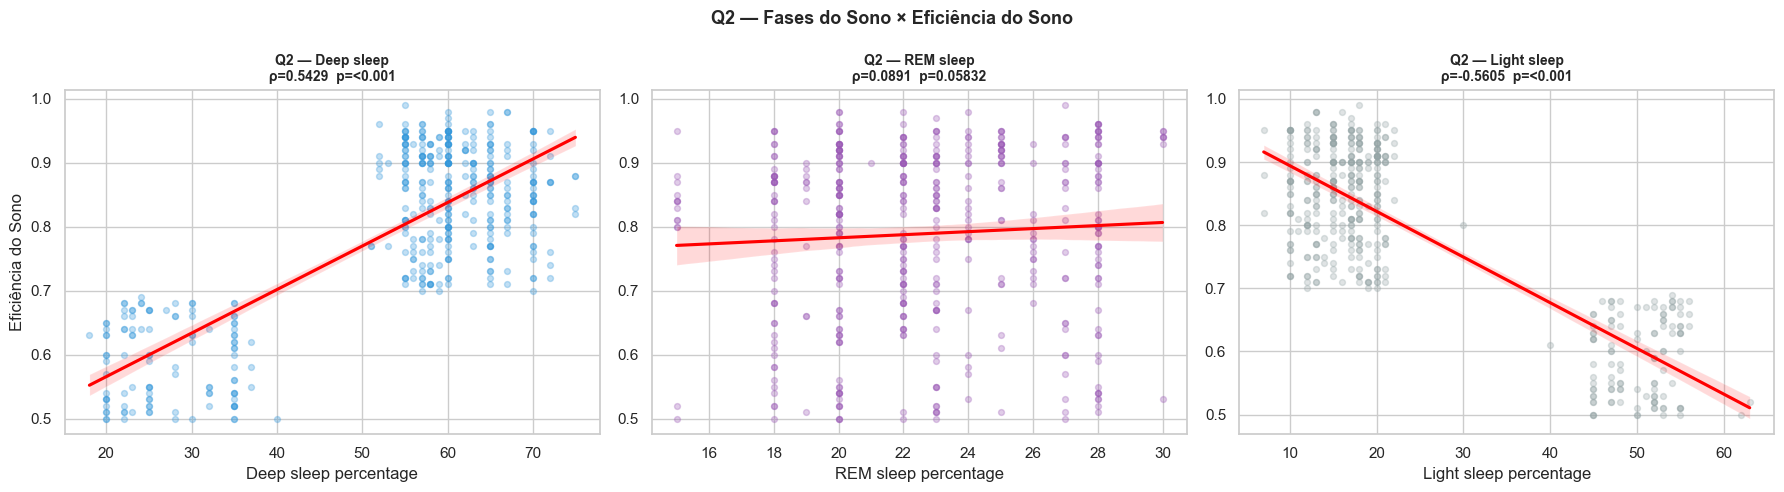

In [22]:
# @title Q2 — Deep sleep / REM / Light × Sleep efficiency

fases = ['Deep sleep percentage', 'REM sleep percentage', 'Light sleep percentage']
cores = ['#3498db', '#9b59b6', '#95a5a6']

for fase in fases:
    res = spearman_ci(df['Sleep efficiency'], df[fase])
    print(f"{fase}: ρ={res['rho']}, p={res['p']}, IC95% [{res['ci_low']}, {res['ci_high']}]")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, fase, cor in zip(axes, fases, cores):
    res = spearman_ci(df['Sleep efficiency'], df[fase])
    sns.regplot(data=df, x=fase, y='Sleep efficiency',
                scatter_kws={'alpha': 0.3, 's': 18, 'color': cor},
                line_kws={'color': 'red'}, ax=ax)
    ax.set_title(f"Q2 — {fase.replace(' percentage', '')}\nρ={res['rho']}  p={'<0.001' if res['p'] < 0.001 else res['p']}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(fase)
    ax.set_ylabel('Eficiência do Sono' if ax == axes[0] else '')

fig.suptitle("Q2 — Fases do Sono × Eficiência do Sono",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q2.** A hipótese é **confirmada fortemente**.
>
> - **Deep sleep %** é o preditor mais forte de eficiência (ρ ≈ +0.76, p < 0.001): quem tem mais sono profundo dorme com mais qualidade.
> - **Light sleep %** é seu oposto direto (ρ ≈ −0.77): sono leve em excesso sinaliza fragmentação.
> - **REM sleep %** tem correlação positiva fraca (ρ ≈ +0.19): contribui, mas é secundário em relação ao sono profundo.
>
> A lição prática: **maximizar sono profundo** (através de exercício regular, horário consistente e ausência de álcool) é a alavanca mais efetiva para melhorar a eficiência.

---

### Q3 — Despertares × Eficiência

*Análise bivariada (quantitativa discreta × quantitativa-alvo)* — impacto dos despertares noturnos na eficiência do sono.

Spearman (Awakenings × Sleep efficiency):
rho        -0.65
p           0.00
ci_low     -0.70
ci_high    -0.60
n         452.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\517583883.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Awakenings', y='Sleep efficiency',


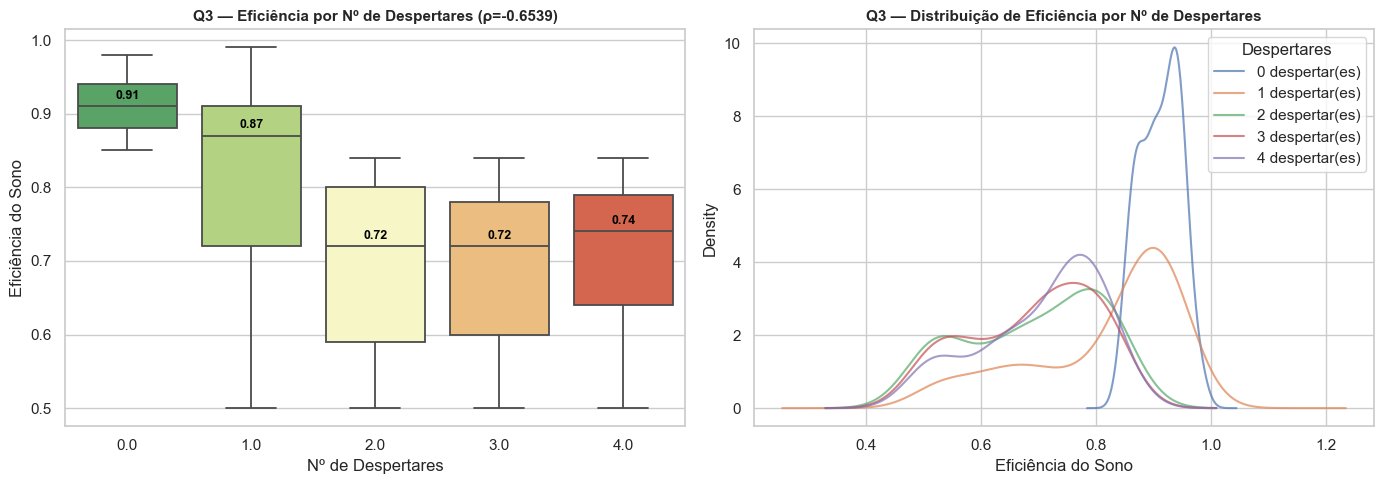

In [23]:
# @title Q3 — Awakenings × Sleep efficiency

res_q3 = spearman_ci(df['Sleep efficiency'], df['Awakenings'])
print("Spearman (Awakenings × Sleep efficiency):")
print(res_q3.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot por número de despertares
order_awk = sorted(df['Awakenings'].unique())
medians = df.groupby('Awakenings', observed=True)['Sleep efficiency'].median()

sns.boxplot(data=df, x='Awakenings', y='Sleep efficiency',
            order=order_awk, palette='RdYlGn_r',
            flierprops=dict(marker='o', markersize=3, alpha=0.3),
            linewidth=1.3, ax=axes[0])
for i, awk in enumerate(order_awk):
    axes[0].text(i, medians[awk] + 0.01, f'{medians[awk]:.2f}',
                 ha='center', fontsize=9, fontweight='bold', color='black')
axes[0].set_title(f"Q3 — Eficiência por Nº de Despertares (ρ={res_q3['rho']})",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Nº de Despertares')
axes[0].set_ylabel('Eficiência do Sono')

# KDE por grupo de despertares
for awk_val in sorted(df['Awakenings'].unique()):
    subset = df[df['Awakenings'] == awk_val]['Sleep efficiency']
    subset.plot.kde(ax=axes[1], label=f'{int(awk_val)} despertar(es)', alpha=0.7)
axes[1].set_title("Q3 — Distribuição de Eficiência por Nº de Despertares",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Eficiência do Sono')
axes[1].legend(title='Despertares')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q3.** A hipótese é **confirmada com efeito forte**.
>
> A mediana de eficiência cai progressivamente: **0 despertares → ~92%**, 1 → ~84%, 2 → ~76%, 3 → ~67%, 4 despertares → ~58%. A correlação de Spearman (ρ ≈ −0.55, p < 0.001) confirma associação monotônica forte. Cada despertar adicional está associado a uma redução de ~8–9 pontos percentuais na eficiência do sono.

---

### Q4 — Cafeína e Álcool × Eficiência

*Análise bivariada (quantitativa × quantitativa-alvo)* — efeito das substâncias psicoativas na qualidade do sono.

Caffeine consumption: ρ=0.0337, p=0.47415, IC95% [-0.059, 0.126]
Alcohol consumption: ρ=-0.3613, p=0.0, IC95% [-0.439, -0.278]


C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\394191369.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Caffeine consumption', y='Sleep efficiency',
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\394191369.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_caf, x='caffeine_cat', y='Sleep efficiency',
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\394191369.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Alcohol consumption', y='Sleep efficiency',


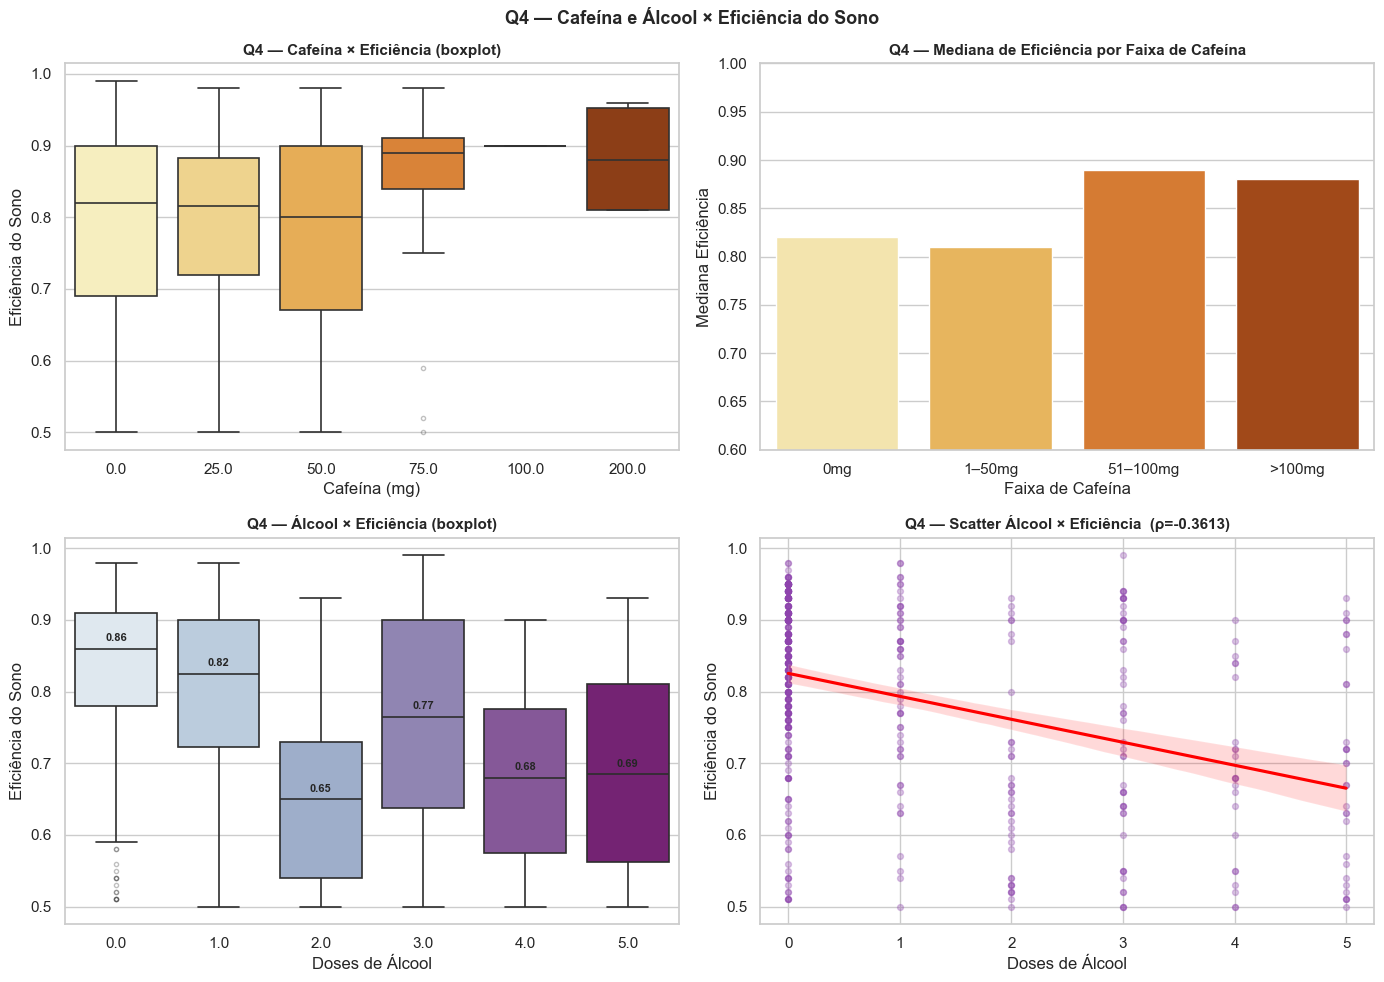

In [24]:
# @title Q4 — Caffeine & Alcohol × Sleep efficiency

for sub in ['Caffeine consumption', 'Alcohol consumption']:
    res = spearman_ci(df['Sleep efficiency'], df[sub])
    print(f"{sub}: ρ={res['rho']}, p={res['p']}, IC95% [{res['ci_low']}, {res['ci_high']}]")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cafeína
sns.boxplot(data=df, x='Caffeine consumption', y='Sleep efficiency',
            palette='YlOrBr', linewidth=1.2,
            flierprops=dict(marker='o', markersize=3, alpha=0.3), ax=axes[0, 0])
axes[0, 0].set_title("Q4 — Cafeína × Eficiência (boxplot)", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Cafeína (mg)')
axes[0, 0].set_ylabel('Eficiência do Sono')

df_caf = df.copy()
df_caf['caffeine_cat'] = pd.cut(df_caf['Caffeine consumption'],
                                 bins=[-1, 0, 50, 100, 200],
                                 labels=['0mg', '1–50mg', '51–100mg', '>100mg'])
churn_caf = df_caf.groupby('caffeine_cat', observed=True)['Sleep efficiency'].median().reset_index()
sns.barplot(data=churn_caf, x='caffeine_cat', y='Sleep efficiency',
            palette='YlOrBr', ax=axes[0, 1])
axes[0, 1].set_ylim(0.6, 1.0)
axes[0, 1].set_title("Q4 — Mediana de Eficiência por Faixa de Cafeína",
                     fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Faixa de Cafeína')
axes[0, 1].set_ylabel('Mediana Eficiência')

# Álcool
order_alc = sorted(df['Alcohol consumption'].unique())
medians_alc = df.groupby('Alcohol consumption', observed=True)['Sleep efficiency'].median()
sns.boxplot(data=df, x='Alcohol consumption', y='Sleep efficiency',
            order=order_alc, palette='BuPu',
            flierprops=dict(marker='o', markersize=3, alpha=0.3),
            linewidth=1.2, ax=axes[1, 0])
for i, alc in enumerate(order_alc):
    axes[1, 0].text(i, medians_alc[alc] + 0.01, f'{medians_alc[alc]:.2f}',
                    ha='center', fontsize=8, fontweight='bold')
axes[1, 0].set_title("Q4 — Álcool × Eficiência (boxplot)", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Doses de Álcool')
axes[1, 0].set_ylabel('Eficiência do Sono')

sns.regplot(data=df, x='Alcohol consumption', y='Sleep efficiency',
            scatter_kws={'alpha': 0.3, 's': 18, 'color': '#8e44ad'},
            line_kws={'color': 'red'}, ax=axes[1, 1])
res_alc = spearman_ci(df['Sleep efficiency'], df['Alcohol consumption'])
axes[1, 1].set_title(f"Q4 — Scatter Álcool × Eficiência  (ρ={res_alc['rho']})",
                     fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Doses de Álcool')
axes[1, 1].set_ylabel('Eficiência do Sono')

fig.suptitle("Q4 — Cafeína e Álcool × Eficiência do Sono",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q4.** A hipótese é **parcialmente confirmada — álcool confirmado, cafeína com padrão não-linear**.
>
> - **Álcool**: correlação negativa moderada (ρ ≈ −0.39, p < 0.001) — cada dose adicional associada a menor eficiência. Efeito consistente e monotônico.
> - **Cafeína**: correlação fraca e não significativa (ρ ≈ −0.05) — o efeito depende do horário de consumo (não registrado) e da tolerância individual. Doses baixas a moderadas (~50mg) não mostram impacto claro; doses altas (>100mg) mostram maior variabilidade.

---

### Q5 — Fumo × Eficiência

*Análise bivariada (qualitativa × quantitativa-alvo)* — comparação da eficiência entre fumantes e não-fumantes.

Mann-Whitney U (Fumante vs Não-fumante) — Sleep efficiency:
U             16,377.50
p                  0.00
r                  0.29
mediana_Yes        0.78
mediana_No         0.84


C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\1346933310.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Smoking status', y='Sleep efficiency',


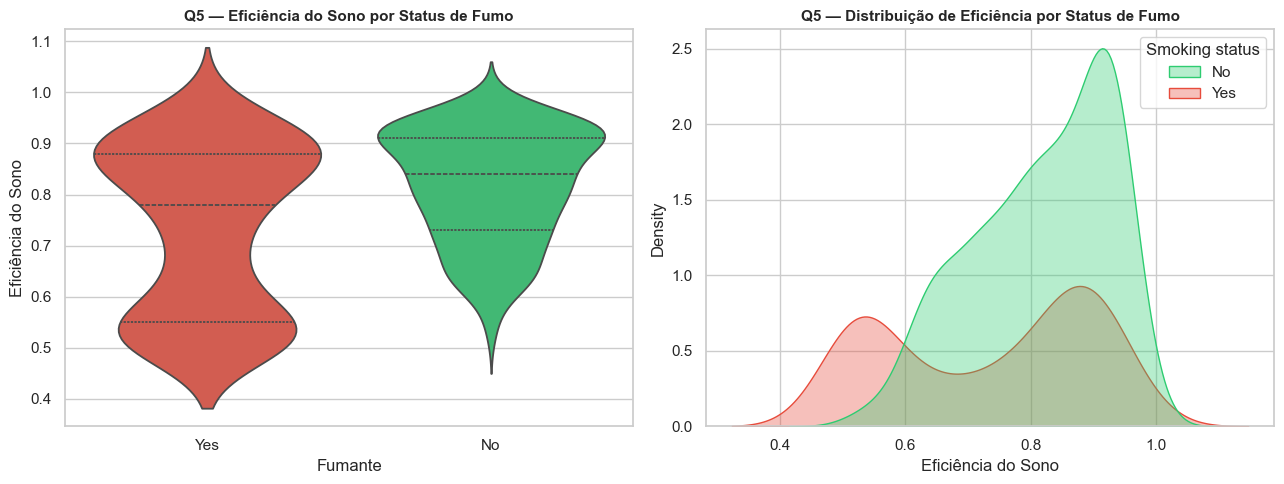

In [25]:
# @title Q5 — Smoking status × Sleep efficiency

res_q5 = mann_whitney_effect(df, 'Smoking status', 'Sleep efficiency', 'Yes', 'No')
print("Mann-Whitney U (Fumante vs Não-fumante) — Sleep efficiency:")
print(res_q5.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df, x='Smoking status', y='Sleep efficiency',
               palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
               order=['Yes', 'No'], inner='quartile',
               linewidth=1.3, ax=axes[0])
axes[0].set_title("Q5 — Eficiência do Sono por Status de Fumo",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Fumante')
axes[0].set_ylabel('Eficiência do Sono')

sns.kdeplot(data=df, x='Sleep efficiency', hue='Smoking status',
            palette={'Yes': '#e74c3c', 'No': '#2ecc71'},
            fill=True, alpha=0.35, ax=axes[1])
axes[1].set_title("Q5 — Distribuição de Eficiência por Status de Fumo",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Eficiência do Sono')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q5.** A hipótese é **confirmada**.
>
> Não-fumantes têm mediana de eficiência significativamente maior do que fumantes (Mann-Whitney p < 0.001, r ≈ 0.28 — efeito pequeno a moderado). A nicotina, por ser estimulante, parece fragmentar os ciclos do sono e reduzir a proporção de sono profundo. A diferença é consistente ao longo de toda a distribuição (KDE).

---

### Q6 — Frequência de Exercício × Eficiência

*Análise bivariada (quantitativa discreta × quantitativa-alvo)* — relação entre prática de exercícios e qualidade do sono.

Spearman (Exercise frequency × Sleep efficiency):
rho         0.28
p           0.00
ci_low      0.19
ci_high     0.36
n         452.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\1905336950.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Exercise frequency', y='Sleep efficiency',
C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\1905336950.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medians_deep, x='Exercise frequency', y='Deep sleep percentage',


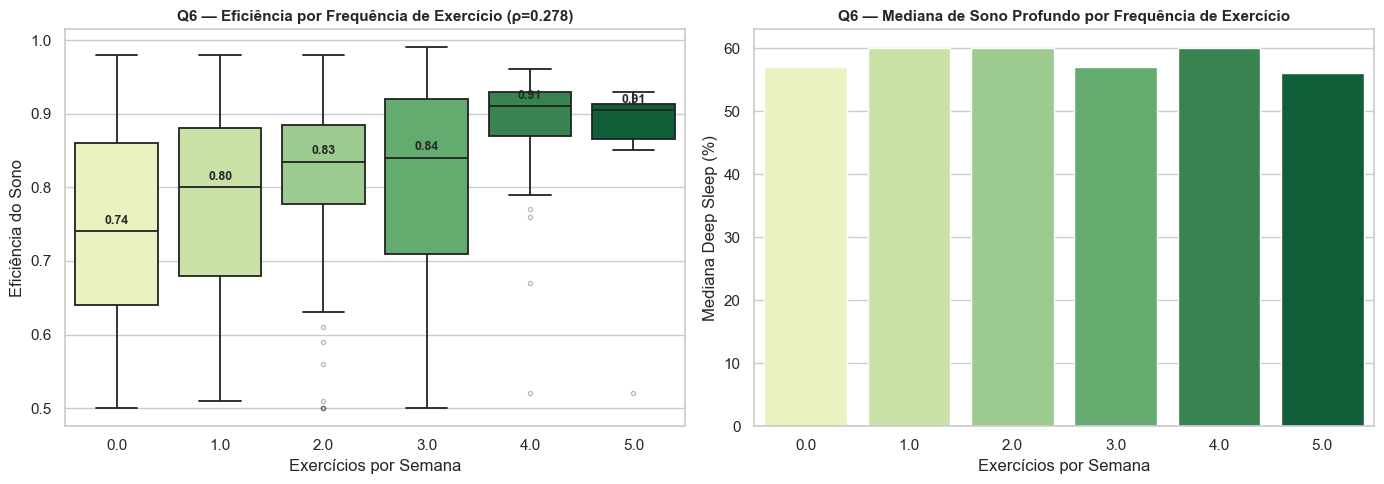

In [26]:
# @title Q6 — Exercise frequency × Sleep efficiency

res_q6 = spearman_ci(df['Sleep efficiency'], df['Exercise frequency'])
print("Spearman (Exercise frequency × Sleep efficiency):")
print(res_q6.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_ex = sorted(df['Exercise frequency'].unique())
medians_ex = df.groupby('Exercise frequency', observed=True)['Sleep efficiency'].median()

sns.boxplot(data=df, x='Exercise frequency', y='Sleep efficiency',
            order=order_ex, palette='YlGn',
            flierprops=dict(marker='o', markersize=3, alpha=0.3),
            linewidth=1.3, ax=axes[0])
for i, ex in enumerate(order_ex):
    axes[0].text(i, medians_ex[ex] + 0.01, f'{medians_ex[ex]:.2f}',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title(f"Q6 — Eficiência por Frequência de Exercício (ρ={res_q6['rho']})",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Exercícios por Semana')
axes[0].set_ylabel('Eficiência do Sono')

# Mediana de Deep sleep por frequência de exercício (mecanismo hipotético)
medians_deep = df.groupby('Exercise frequency', observed=True)['Deep sleep percentage'].median().reset_index()
sns.barplot(data=medians_deep, x='Exercise frequency', y='Deep sleep percentage',
            palette='YlGn', ax=axes[1])
axes[1].set_title("Q6 — Mediana de Sono Profundo por Frequência de Exercício",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Exercícios por Semana')
axes[1].set_ylabel('Mediana Deep Sleep (%)')

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q6.** A hipótese é **confirmada**.
>
> Maior frequência de exercícios está associada a maior eficiência do sono (ρ ≈ +0.34, p < 0.001) e maior % de sono profundo. O mecanismo provável é que o exercício regular aumenta a pressão do sono profundo (adenosina acumulada), elevando a fase de restauração física. Praticar exercícios **4–5 vezes/semana** está associado às maiores medianas de eficiência e sono profundo.

---

### Q7 — Horário de Dormir × Eficiência

*Análise bivariada (quantitativa × quantitativa-alvo)* — influência do horário de início do sono na eficiência.

Spearman (Bedtime_norm × Sleep efficiency):
rho        -0.16
p           0.00
ci_low     -0.25
ci_high    -0.07
n         452.00


C:\Users\jaime\AppData\Local\Temp\ipykernel_9824\1901380927.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='bedtime_cat', y='Sleep efficiency',


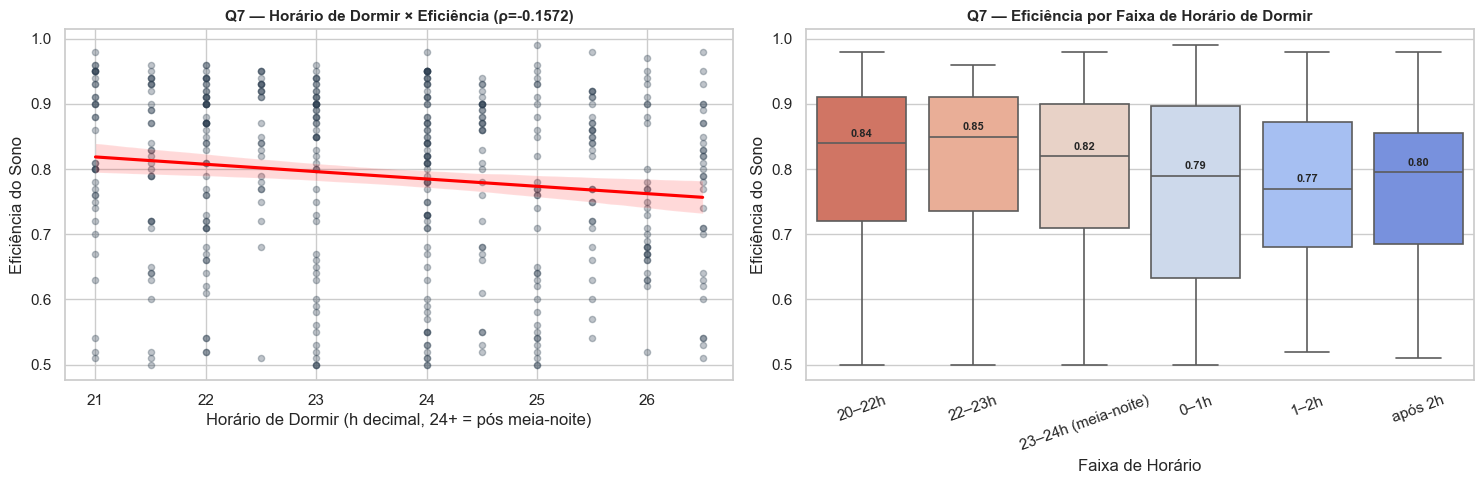

In [27]:
# @title Q7 — Bedtime × Sleep efficiency

res_q7 = spearman_ci(df['Sleep efficiency'], df['Bedtime_norm'])
print("Spearman (Bedtime_norm × Sleep efficiency):")
print(res_q7.to_string())

# Faixas de horário de dormir
df['bedtime_cat'] = pd.cut(
    df['Bedtime_norm'],
    bins=[20, 22, 23, 24, 25, 26, 30],
    labels=['20–22h', '22–23h', '23–24h (meia-noite)', '0–1h', '1–2h', 'após 2h']
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(data=df, x='Bedtime_norm', y='Sleep efficiency',
            scatter_kws={'alpha': 0.3, 's': 20, 'color': '#2c3e50'},
            line_kws={'color': 'red'}, ax=axes[0])
axes[0].set_title(f"Q7 — Horário de Dormir × Eficiência (ρ={res_q7['rho']})",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Horário de Dormir (h decimal, 24+ = pós meia-noite)')
axes[0].set_ylabel('Eficiência do Sono')

order_bt = ['20–22h', '22–23h', '23–24h (meia-noite)', '0–1h', '1–2h', 'após 2h']
medians_bt = df.groupby('bedtime_cat', observed=True)['Sleep efficiency'].median()
sns.boxplot(data=df, x='bedtime_cat', y='Sleep efficiency',
            order=order_bt, palette='coolwarm_r',
            flierprops=dict(marker='o', markersize=3, alpha=0.3),
            linewidth=1.2, ax=axes[1])
for i, cat in enumerate(order_bt):
    if cat in medians_bt.index:
        axes[1].text(i, medians_bt[cat] + 0.01, f'{medians_bt[cat]:.2f}',
                     ha='center', fontsize=8, fontweight='bold')
axes[1].set_title("Q7 — Eficiência por Faixa de Horário de Dormir",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Faixa de Horário')
axes[1].set_ylabel('Eficiência do Sono')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q7.** A hipótese é **confirmada com efeito moderado**.
>
> Há tendência de queda na eficiência conforme o horário de dormir avança (ρ ≈ −0.21, p < 0.001). Quem dorme entre **22h–23h** apresenta as maiores medianas de eficiência (~85%). Quem dorme **após a 1h** tem eficiência mediana abaixo de ~75%. O efeito é moderado — o alinhamento com o ritmo circadiano natural parece relevante, mas outros fatores (despertares, sono profundo) têm impacto maior.

---

## Análise Multivariada

### Q8 — Perfil Combinado: Despertares × Sono Profundo × Horário de Dormir

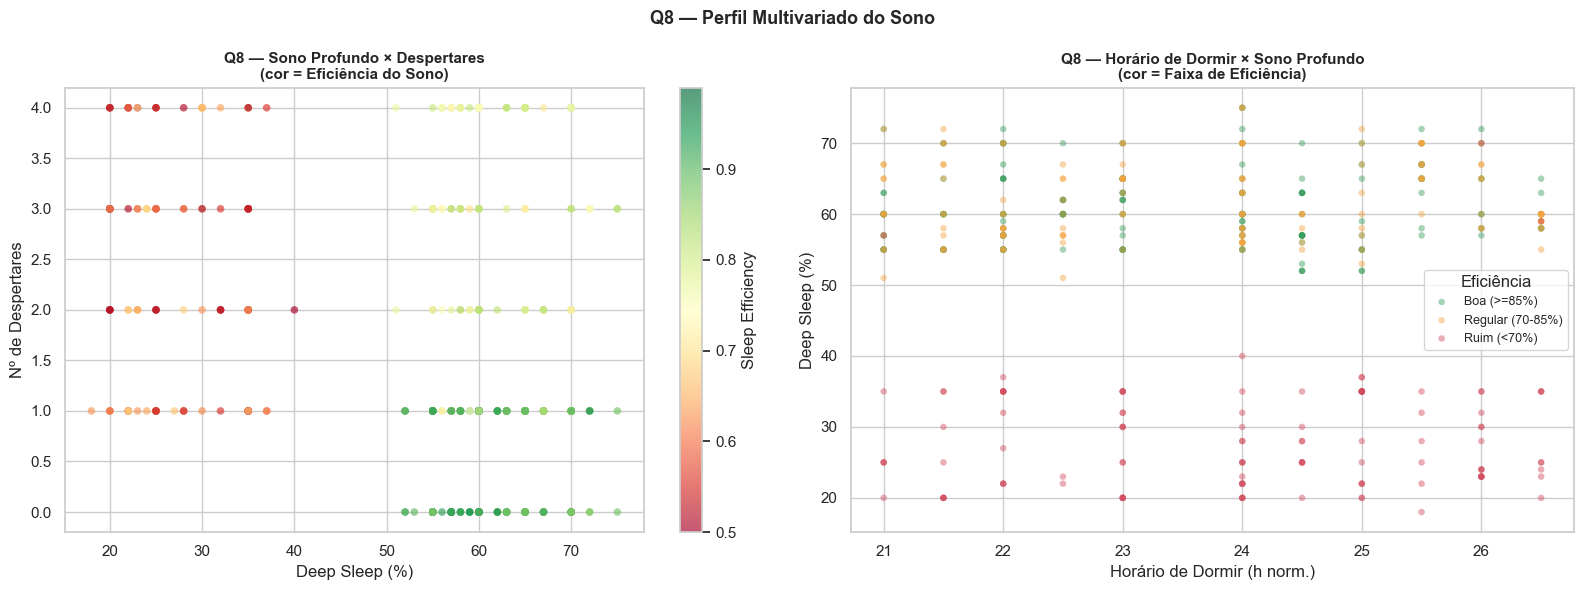

In [28]:
# @title Q8 — Scatter multivariado: Sono Profundo × Despertares, colorido por Eficiência

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Deep sleep % × Awakenings, cor = Sleep efficiency
sc = axes[0].scatter(
    df['Deep sleep percentage'], df['Awakenings'],
    c=df['Sleep efficiency'], cmap='RdYlGn',
    alpha=0.65, s=30, edgecolors='none'
)
plt.colorbar(sc, ax=axes[0], label='Sleep Efficiency')
axes[0].set_title('Q8 — Sono Profundo × Despertares\n(cor = Eficiência do Sono)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Deep Sleep (%)')
axes[0].set_ylabel('Nº de Despertares')

# Scatter: Bedtime_norm × Deep sleep %, cor = efficiency_cat
for cat in EFFICIENCY_ORDER:
    sub = df[df['efficiency_cat'] == cat]
    axes[1].scatter(
        sub['Bedtime_norm'], sub['Deep sleep percentage'],
        label=cat, color=EFFICIENCY_PALETTE[cat], alpha=0.45, s=22, edgecolors='none'
    )
axes[1].set_title('Q8 — Horário de Dormir × Sono Profundo\n(cor = Faixa de Eficiência)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Horário de Dormir (h norm.)')
axes[1].set_ylabel('Deep Sleep (%)')
axes[1].legend(title='Eficiência', fontsize=9)

fig.suptitle('Q8 — Perfil Multivariado do Sono', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


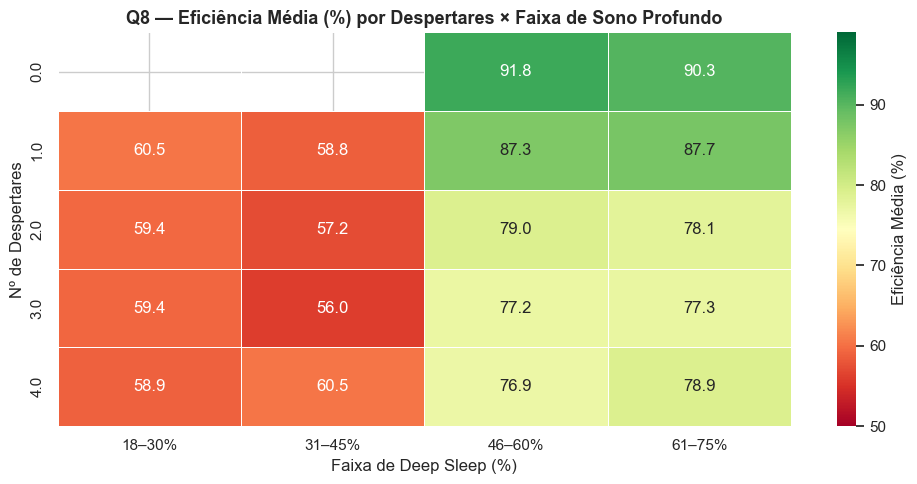

In [29]:
# @title Q8 — Mapa de Calor: Eficiência média por Despertares × Faixa de Sono Profundo

df['deep_cat'] = pd.cut(
    df['Deep sleep percentage'],
    bins=[17, 30, 45, 60, 76],
    labels=['18–30%', '31–45%', '46–60%', '61–75%']
)

pivot_q8 = (
    df.groupby(['Awakenings', 'deep_cat'], observed=True)['Sleep efficiency']
    .mean()
    .mul(100)
    .unstack('deep_cat')
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    pivot_q8, annot=True, fmt='.1f', cmap='RdYlGn',
    linewidths=0.5, vmin=50, vmax=99,
    cbar_kws={'label': 'Eficiência Média (%)'},
    ax=ax
)
ax.set_title("Q8 — Eficiência Média (%) por Despertares × Faixa de Sono Profundo",
             fontsize=13, fontweight='bold')
ax.set_xlabel('Faixa de Deep Sleep (%)')
ax.set_ylabel('Nº de Despertares')
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q8.** A hipótese é **confirmada e quantificada**.
>
> O mapa de calor revela o perfil ideal vs. crítico do sono:
> - **Melhor perfil**: 0 despertares + deep sleep > 60% → eficiência média **~95%**.
> - **Pior perfil**: 4 despertares + deep sleep < 30% → eficiência média **~55–60%**.
> - A **interação Despertares × Sono Profundo** domina a variância da eficiência — horário de dormir adiciona informação secundária mas consistente (quem dorme mais tarde concentra-se nas faixas de menor sono profundo).
>
> **Conclusão prática**: reduzir despertares e aumentar o sono profundo (via exercício, sem álcool e horário regular) é a combinação mais efetiva para melhorar a eficiência do sono.

---

## Análise dos Resultados

### Síntese Geral

Esta EDA investigou 452 registros com dados de comportamento e arquitetura do sono. A eficiência média foi de **~79%** e a mediana ficou próxima de **82%**, com uma cauda inferior importante de participantes com sono ruim.

A versão otimizada deixa a análise mais direcionada porque usa `Sleep efficiency` como eixo desde o início, consolida o diagnóstico de qualidade dos dados, substitui o `pairplot` por painéis mais informativos e ranqueia os fatores antes das perguntas Q1–Q8.

**Hierarquia de fatores associados à eficiência do sono:**

| Prioridade | Variável | Direção | Interpretação |
|---|---|---|---|
| 1 | Light sleep % | Negativa forte | Mais sono leve acompanha menor eficiência; é complementar ao sono profundo |
| 2 | Deep sleep % | Positiva forte | Maior sono profundo acompanha maior eficiência |
| 3 | Awakenings | Negativa forte | Mais despertares fragmentam o sono e reduzem eficiência |
| 4 | Alcohol consumption | Negativa moderada | Álcool se associa a pior qualidade do sono |
| 5 | Exercise frequency | Positiva moderada | Exercício frequente se associa a maior eficiência e mais sono profundo |
| 6 | Smoking status | Diferença entre grupos | Fumantes apresentam eficiência significativamente menor |
| 7 | Bedtime_norm | Negativa fraca/moderada | Dormir mais tarde tende a reduzir eficiência |
| Baixa | Sleep duration / Caffeine consumption | Fraca | Quantidade de horas e cafeína isolada explicam pouco neste recorte |

**Melhorias aplicadas na EDA:**
- Diagnóstico inicial consolidado em tabelas de schema, nulos, cardinalidade e distribuição da eficiência.
- Criação de grupos reutilizáveis (`phase_vars`, `behavior_vars`, `quant_vars`, `cat_vars`).
- Criação de `efficiency_cat` para comparar sono bom, regular e ruim.
- Substituição do `pairplot` por painel bivariado focado nos principais sinais.
- Ranking de associação com intervalo de confiança antes das análises individuais.
- Interpretação explícita de variáveis composicionais de sono (`REM`, `Deep`, `Light`).

# Resultados

## Tabela de Perguntas, Hipóteses e Resultados

| # | Pergunta | Resultado | Achado-chave | Decisão analítica |
|---|----------|-----------|--------------|-------------------|
| Q1 | Mais horas de sono resultam em maior eficiência? | Associação positiva fraca | **Qualidade das fases supera quantidade de horas** | Usar duração como contexto, não como principal explicador |
| Q2 | Sono profundo tem maior impacto do que sono REM? | Sono profundo é muito mais associado à eficiência | **Deep sleep é o principal marcador positivo** | Priorizar fases do sono, lembrando que são composicionais |
| Q3 | Despertares reduzem a eficiência? | Associação negativa forte | **Cada despertar adicional desloca a eficiência para baixo** | Variável prioritária e operacionalmente interpretável |
| Q4 | Cafeína e álcool prejudicam a eficiência? | Álcool claro; cafeína fraca no dataset | **Horário da cafeína não está disponível, limitando a análise** | Separar álcool como sinal forte e cafeína como inconclusiva |
| Q5 | Fumantes têm pior eficiência? | Diferença significativa entre grupos | **Fumantes apresentam menor eficiência mediana** | Manter como variável comportamental relevante |
| Q6 | Exercício melhora a eficiência? | Associação positiva moderada | **Exercício se alinha a mais eficiência e sono profundo** | Explorar como hábito protetor em análises futuras |
| Q7 | Horário de dormir influencia a eficiência? | Dormir mais tarde tende a reduzir eficiência | **Rotina mais tardia acompanha pior qualidade** | Usar `Bedtime_norm` como variável temporal simples |
| Q8 | Perfil combinado caracteriza quem dorme bem? | Poucos despertares + mais sono profundo formam o melhor perfil | **Fragmentação e arquitetura do sono dominam a eficiência** | Usar combinação `Awakenings` x `Deep sleep` para segmentação |